In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
import matplotlib.dates as mdatesx
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
from scipy.interpolate import make_interp_spline
import calendar

In [3]:
ANIO = 2026
MES = 2

df = pd.DataFrame()
df["anio"] = ANIO
df["mes"] = MES

fecha_corte = pd.Timestamp(year=ANIO, month=MES, day=1) + pd.offsets.MonthEnd(0)


In [4]:
precios_db = pd.read_excel("Precios_BBDD.xlsx", sheet_name='PBA')
precios_db.columns = precios_db.columns.str.strip()

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

precios_db['seg_patrim_seg_financ_pba'] = precios_db['seguros_patrimoniales_pba'] + precios_db['servicios_financieros_pba']
precios_db['alim_bebid_no_alc_pba'] = precios_db['alimentos_no_alc_pba'] + precios_db['bebidas_no_alc_pba']
precios_db['equipa_mantenim_pba'] = precios_db['equipamiento_pba'] + precios_db['mantenimiento_pba']

precios_db['fecha'] = pd.to_datetime(precios_db['fecha'])
precios_db = precios_db.set_index('fecha')

db_filtrado = precios_db.loc[:fecha_corte].copy()

precios_db.tail(5)

,nivel_general_pba,alimentos_no_alc_pba,alimentos_pba,pan_cer_pba,carnes_der_pba,pescados_mar_pba,leche_hue_pba,aceites_gra_pba,frutas_pba,verduras_leg_pba,azucar_gol_pba,condimentos_pba,bebidas_no_alc_pba,café_pba,te_pba,aguas_pba,bebidas_pba,jugo_frutas_pba,bebidas_alc_tabaco_pba,bebidas_alc_pba,tabaco_pba,prendas_calzado_pba,prendas_accesorios_pba,calzado_pba,vivienda_pba,alquiler_pba,mantenimiento_pba,suministro_agua_pba,electricidad_pba,equipamiento_pba,muebles_pba,artefactos_hogar_pba,bs_ss_conservacion_hogar_pba,salud_pba,medicamentos_pba,servicios_pba,seguros_pba,transporte_pba,adquisición_veh_pba,funcionamiento_eq_trans_pba,servicios_trans_pba,informacion_com_pba,equipos_comunicacion_pba,servicios_comunicacion_pba,recreacion_cultura_pba,bienes_culturales_pba,servicios_culturales_pba,paquetes_turisticos_pba,diarios_papeleria_pba,educacion_pba,restaurantes_hotel_pba,servicio_alimentos_bebidas_pba,servicios_alojamiento_pba,seguros_patrimoniales_pba,seguros_patrimoniales_pba.1,servicios_financieros_pba,bienes_servicios_varios_pba,cuidado_efectos_personales_pba,servicios_diversos_pba,seg_patrim_seg_financ_pba,alim_bebid_no_alc_pba,equipa_mantenim_pba
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-01,540.46,486.69,480.80,492.56,494.02,413.03,507.84,466.27,398.46,392.51,483.28,659.58,540.30,560.64,433.72,537.62,604.54,547.05,545.37,513.19,582.64,346.68,335.04,355.11,737.21,985.15,394.07,464.92,705.05,416.43,409.80,317.65,452.17,565.12,473.53,676.01,571.07,545.02,420.33,541.08,702.36,639.97,384.61,670.35,444.80,371.43,684.69,324.42,504.49,527.93,554.32,556.26,500.84,620.96,614.95,695.74,516.26,513.85,727.47,1316.70,1026.99,810.50
2025-11-01,554.40,498.84,493.01,500.33,522.24,418.75,511.23,471.83,420.97,374.68,491.79,658.17,552.00,567.48,440.97,547.48,623.11,554.87,553.75,517.66,595.54,338.25,328.86,341.47,760.40,1026.37,414.98,467.89,722.28,427.44,418.82,315.08,465.04,578.11,485.25,691.62,582.70,562.44,434.13,560.97,711.17,651.79,374.14,684.81,468.22,377.08,684.69,365.87,530.31,541.08,572.51,574.47,518.56,638.08,633.17,699.20,530.80,525.20,739.79,1337.28,1050.84,842.42
2025-12-01,572.59,512.30,505.85,505.26,550.46,426.22,518.99,489.02,437.76,357.00,503.37,669.17,571.04,590.35,441.02,576.01,651.04,572.40,572.06,529.15,621.73,343.98,334.07,347.72,790.83,1076.57,421.40,489.03,746.47,434.10,419.63,319.15,475.01,591.96,491.75,715.05,596.07,594.25,447.33,593.73,758.56,668.54,367.33,704.37,484.04,385.24,684.69,405.68,534.31,541.21,595.10,596.23,564.05,648.47,643.23,713.73,540.26,534.03,751.29,1362.20,1083.34,855.50
2026-01-01,588.44,531.02,525.59,511.89,571.45,428.86,526.52,495.82,481.08,412.97,511.41,682.76,580.46,585.33,440.19,594.42,667.88,580.44,586.61,530.37,651.71,348.57,338.43,351.51,816.50,1127.55,425.83,498.68,763.64,436.48,422.57,315.93,480.90,604.97,504.07,728.65,609.47,607.98,454.87,601.29,810.63,683.64,379.49,719.82,501.12,388.65,705.29,427.85,555.09,544.50,614.62,613.37,649.17,664.48,660.55,713.40,554.15,545.23,780.59,1377.88,1111.48,862.31
2026-02-01,610.13,545.91,540.90,519.49,600.47,442.35,530.54,505.36,497.23,418.44,520.21,691.67,591.57,598.48,445.08,594.58,685.09,595.15,593.35,542.95,651.71,346.67,334.46,352.46,885.83,1188.49,450.13,566.39,846.12,440.68,415.45,316.38,490.40,622.31,517.15,752.60,625.13,618.66,462.68,608.30,843.31,709.53,393.35,747.14,520.25,397.89,761.25,446.09,579.22,545.27,634.07,633.52,649.21,687.54,683.98,731.85,572.69,558.65,826.46,1419.39,1137.48,890.81


In [5]:
db_filtrado['ipc_pba_mm'] = precios_db['nivel_general_pba'].pct_change(periods=1) * 100
db_filtrado['ipc_pba_yy'] = precios_db['nivel_general_pba'].pct_change(periods=12) * 100

In [6]:
# Listas de variables


var1_vivienda_ss_basicos = [    'vivienda_pba',
                                'recreacion_cultura_pba',
                                'servicios_comunicacion_pba',
                                'seg_patrim_seg_financ_pba',
                                'bienes_servicios_varios_pba',
                                'restaurantes_hotel_pba',
                                'salud_pba',
                                'alim_bebid_no_alc_pba',
                                'transporte_pba',
                                'bebidas_alc_tabaco_pba',
                                'equipamiento_pba',
                                'educacion_pba',
                                'prendas_calzado_pba'
                            
                            ]

var2_sum_agua_expensas = [      'suministro_agua_pba',
                                'electricidad_pba',
                                'servicios_culturales_pba',
                                'servicios_diversos_pba',
                                'mantenimiento_pba'
                                ]

var3_hogar = [                  'vivienda_pba',
                                'recreacion_cultura_pba',
                                'bienes_servicios_varios_pba',
                                'equipamiento_pba'
                                 ]

In [7]:
# Listas de etiquetas

etq1_vivienda_ss_basicos = [    
                                'Vivienda y servicios básicos',
                                'Recreación y Cultura',
                                'Información y comunicación',
                                'Seguros patrimoniales y servicios financieros',
                                'Bienes y servicios varios',
                                'Restaurantes y hoteles',
                                'Salud',
                                'Alimentos y Bebidas no alcohólicas',
                                'Transporte',
                                'Bebidas Alcohólicas y Tabaco',
                                'Equipamiento del hogar',
                                'Educación',
                                'Prendas de Vestir y Calzado'

                            ]

etq2_sumin_agua = [             
                                'Suministro de agua y \n expensas',
                                'Electricidad, gas y otros \n combustibles',
                                'Servicios culturales',
                                'Servicios diversos',
                                'Mantenimiento y reparación \n de la vivienda'

                            ]

etq3_hogar = [                 
                                'Vivienda y servicios básicos',
                                'Recreación y Cultura',
                                'Bienes y servicios varios',
                                'Equipamiento del hogar'
 ]

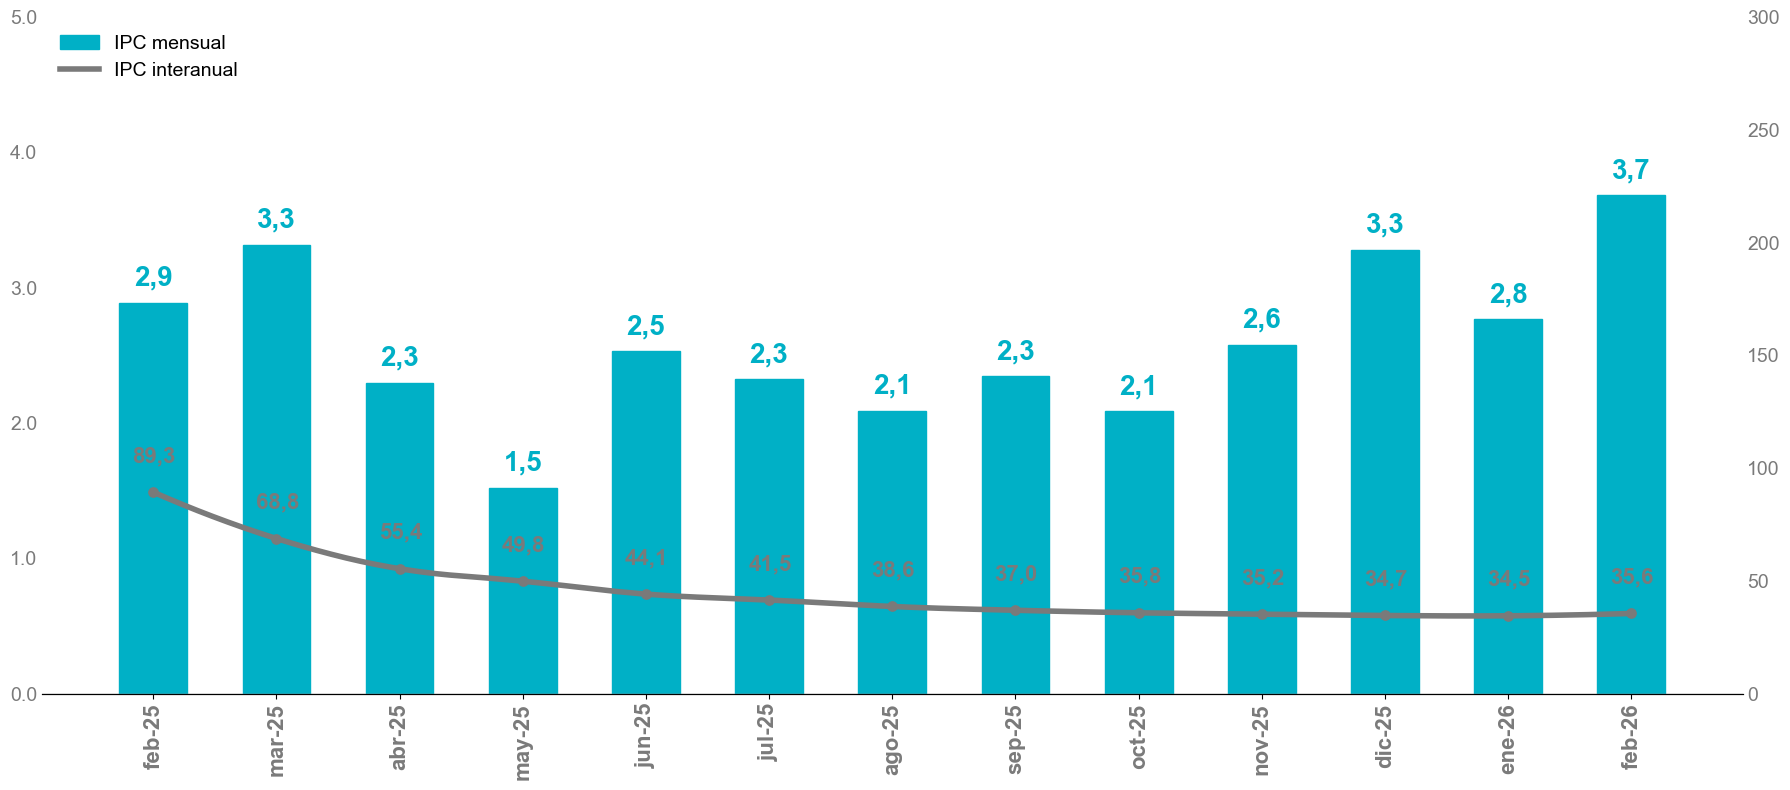

In [8]:
# -----------------------------
# CONFIG EJES
# -----------------------------
y_left_min, y_left_max = 0, 5      # IPC mensual
y_right_min, y_right_max = 0, 300   # IPC interanual

# -----------------------------
# DATA
# -----------------------------
df_yy = db_filtrado['ipc_pba_yy'].tail(13).copy()
df_mm = db_filtrado['ipc_pba_mm'].tail(13).copy()

df_mm = df_mm.reindex(df_yy.index)

x = np.arange(len(df_yy))

# -----------------------------
# FIGURA
# -----------------------------
plt.rcParams["font.family"] = "Arial"

fig, ax_left = plt.subplots(figsize=(18,8))
ax_right = ax_left.twinx()

# -----------------------------
# BARRAS (IPC mensual)
# -----------------------------
ax_left.bar(
    x,
    df_mm.values,
    width=0.55,
    color="#00B0C6",
    edgecolor="#00B0C6",
    zorder=2,
    label="IPC mensual"
)

for i, v in enumerate(df_mm):

    ax_left.text(
        x[i],
        v+0.08,
        f"{v:.1f}".replace(".",","),
        ha="center",
        va="bottom",
        fontsize=20,
        color="#00B0C6",
        fontweight="bold"
    )

# -----------------------------
# LÍNEA (IPC interanual)
# -----------------------------
y = df_yy.values

if len(x)>3:

    x_smooth=np.linspace(x.min(),x.max(),300)

    spline=make_interp_spline(x,y,k=2)

    y_smooth=spline(x_smooth)

    ax_right.plot(
        x_smooth,
        y_smooth,
        color="#7A7A7A",
        linewidth=4,
        zorder=4,
        label="IPC interanual"
    )

else:

    ax_right.plot(
        x,
        y,
        color="#7A7A7A",
        linewidth=4,
        zorder=4,
        label="IPC interanual"
    )

# puntos originales
ax_right.scatter(
    x,
    y,
    color="#7A7A7A",
    s=45,
    zorder=5
)

# LABELS DE TODOS LOS PUNTOS DE LA LÍNEA
for xi, yi in zip(x, y):

    ax_right.text(
        xi - 0.17 ,
        yi + 16,
        f"{yi:.1f}".replace(".", ","),
        fontsize=16,
        color="#7A7A7A",
        fontweight="bold",
        va="center"
    )

# -----------------------------
# EJE X
# -----------------------------
meses_esp = ['ene','feb','mar','abr','may','jun',
             'jul','ago','sep','oct','nov','dic']

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_yy.index
]

ax_left.set_xticks(x)
ax_left.set_xticklabels(fechas_esp, rotation=90)

# -----------------------------
# EJES
# -----------------------------
ax_left.set_ylim(y_left_min,y_left_max)
ax_right.set_ylim(y_right_min,y_right_max)

ax_left.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.1f")
)

ax_right.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.0f")
)

ax_left.tick_params(axis='y',length=0)
ax_right.tick_params(axis='y',length=0)

# -----------------------------
# ESTILO
# -----------------------------
for ax in [ax_left,ax_right]:
    ax.spines["top"].set_visible(False)

ax_left.spines["left"].set_visible(False)
ax_left.spines["right"].set_visible(False)

ax_right.spines["left"].set_visible(False)
ax_right.spines["right"].set_visible(False)

ax_left.axhline(0,color="#BDBDBD",linewidth=1)

for lbl in ax_left.get_xticklabels():
    lbl.set_fontsize(16)
    lbl.set_fontweight("bold")
    lbl.set_color("#7A7A7A")

for lbl in ax_left.get_yticklabels():
    lbl.set_fontsize(14)
    lbl.set_color("#7A7A7A")

for lbl in ax_right.get_yticklabels():
    lbl.set_fontsize(14)
    lbl.set_color("#7A7A7A")

# -----------------------------
# LEYENDA
# -----------------------------
h1,l1=ax_left.get_legend_handles_labels()
h2,l2=ax_right.get_legend_handles_labels()

ax_left.legend(
    h1+h2,
    l1+l2,
    frameon=False,
    fontsize=14,
    loc="upper left"
)

plt.tight_layout()
plt.show()

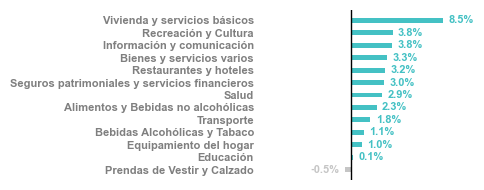

In [9]:
# Calcular variación porcentual
df_vi = db_filtrado[var1_vivienda_ss_basicos].pct_change(periods=1) * 100

# Reemplazar NaN por -100
df_vi = df_vi.fillna(-100)

# Convertir a vector
variacion = df_vi.tail(1).values.flatten()

# ===== ORDENAR DE MAYOR A MENOR =====
idx = np.argsort(variacion)[::-1]
variacion = variacion[idx]
etq1_vivienda_ss_basicos = np.array(etq1_vivienda_ss_basicos)[idx]

# Crear figura
fig, ax = plt.subplots(figsize=(5, 2))

# Colores según signo
colores = ["#44C1C4" if v > 0 else "#C5C5C5" for v in variacion]

# Posiciones en eje Y
y = range(len(etq1_vivienda_ss_basicos))

# Barras
ax.barh(
    y,
    variacion,
    color=colores,
    height=0.4
)

# Invertir eje (para que el mayor quede arriba)
ax.invert_yaxis()

# Línea en cero
ax.axvline(0, color='black', linewidth=1)

# Simetría del eje X
max_val = max(abs(variacion))
ax.set_xlim(-max_val, max_val)

# Etiquetas Y
ax.set_yticks(y)
ax.set_yticklabels(
    etq1_vivienda_ss_basicos,
    fontname="Arial",
    fontsize=8,
    color="#7F7F7F",
    fontweight='bold'
)
ax.tick_params(axis='y', length=0)

# Quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Sin grid ni eje X
ax.xaxis.grid(False)
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    color = "#44C1C4" if v > 0 else "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=8,
        color=color,
        fontweight="bold"
    )

# Etiquetas limpias
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

# Guardar (opcional)
# plt.savefig(os.path.join(ruta_completa, '5. Desagregado_barras_hor_AA.png'),
#             dpi=300,
#             bbox_inches='tight')

plt.show()

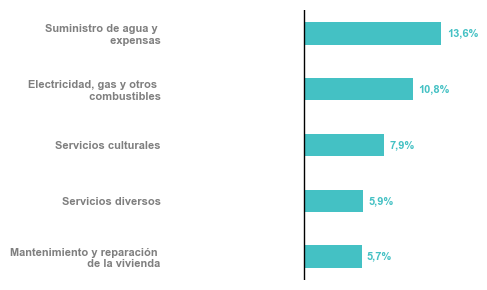

In [10]:
# Calcular variación porcentual
df_vi = db_filtrado[var2_sum_agua_expensas].pct_change(periods=1) * 100

# Reemplazar NaN por -100
df_vi = df_vi.fillna(-100)

# Convertir a vector
variacion = df_vi.tail(1).values.flatten()

# ===== ORDENAR DE MAYOR A MENOR =====
idx = np.argsort(variacion)[::-1]
variacion = variacion[idx]
etq1_vivienda_ss_basicos = np.array(etq2_sumin_agua)[idx]

# Crear figura
fig, ax = plt.subplots(figsize=(5, 3))

# Colores según signo
colores = ["#44C1C4" if v > 0 else "#C5C5C5" for v in variacion]

# Posiciones en eje Y
y = range(len(etq2_sumin_agua))

# Barras
ax.barh(
    y,
    variacion,
    color=colores,
    height=0.4
)

# Invertir eje (para que el mayor quede arriba)
ax.invert_yaxis()

# Línea en cero
ax.axvline(0, color='black', linewidth=1)

# Simetría del eje X
max_val = max(abs(variacion))
ax.set_xlim(-max_val, max_val)

# Etiquetas Y
ax.set_yticks(y)
ax.set_yticklabels(
    etq1_vivienda_ss_basicos,
    fontname="Arial",
    fontsize=8,
    color="#7F7F7F",
    fontweight='bold'
)
ax.tick_params(axis='y', length=0)

# Quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Sin grid ni eje X
ax.xaxis.grid(False)
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    color = "#44C1C4" if v > 0 else "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%".replace(".", ","),
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=8,
        color=color,
        fontweight="bold"
    )

# Etiquetas limpias
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

# Guardar (opcional)
# plt.savefig(os.path.join(ruta_completa, '5. Desagregado_barras_hor_AA.png'),
#             dpi=300,
#             bbox_inches='tight')

plt.show()

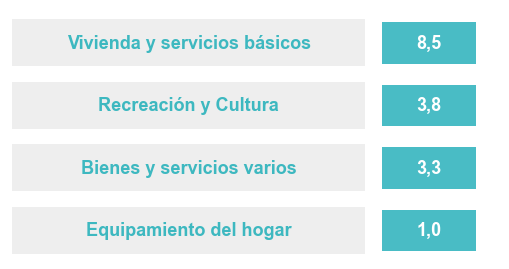

In [11]:
# --------------------------
# Datos
# --------------------------
hogar_var = (
    db_filtrado[var3_hogar]
    .pct_change(periods=1)
    .mul(100)
    .tail(1)
    .iloc[0]
)

# --------------------------
# Figura
# --------------------------
alto_fila = 1.2
fig, ax = plt.subplots(figsize=(5.2, len(etq3_hogar) * 0.7))

ax.set_xlim(0, 10)
ax.set_ylim(0, len(etq3_hogar) * alto_fila)

# --------------------------
# Dibujar filas
# --------------------------
for i, (etq, valor) in enumerate(zip(etq3_hogar, hogar_var)):

    # invertir para que el primero quede arriba
    y = (len(etq3_hogar) - 1 - i) * alto_fila

    # Fondo gris
    ax.add_patch(
        Rectangle(
            (0.05, y + 0.1),
            7.2,
            0.9,
            facecolor="#EEEEEE",
            edgecolor="none"
        )
    )

    # Caja celeste
    ax.add_patch(
        Rectangle(
            (7.6, y + 0.15),
            1.9,
            0.8,
            facecolor="#49BCC5",
            edgecolor="none"
        )
    )

    # Texto izquierdo
    ax.text(
        3.65,
        y + 0.55,
        etq,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="#3DB8C0",
        family="Arial"
    )

    # Valor derecho
    ax.text(
        8.55,
        y + 0.55,
        f"{valor:.1f}".replace(".", ","),
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="white",
        family="Arial"
    )

# --------------------------
# Estilo
# --------------------------
ax.axis("off")
plt.savefig('Hogar.png', dpi=300)

plt.tight_layout()
plt.show()

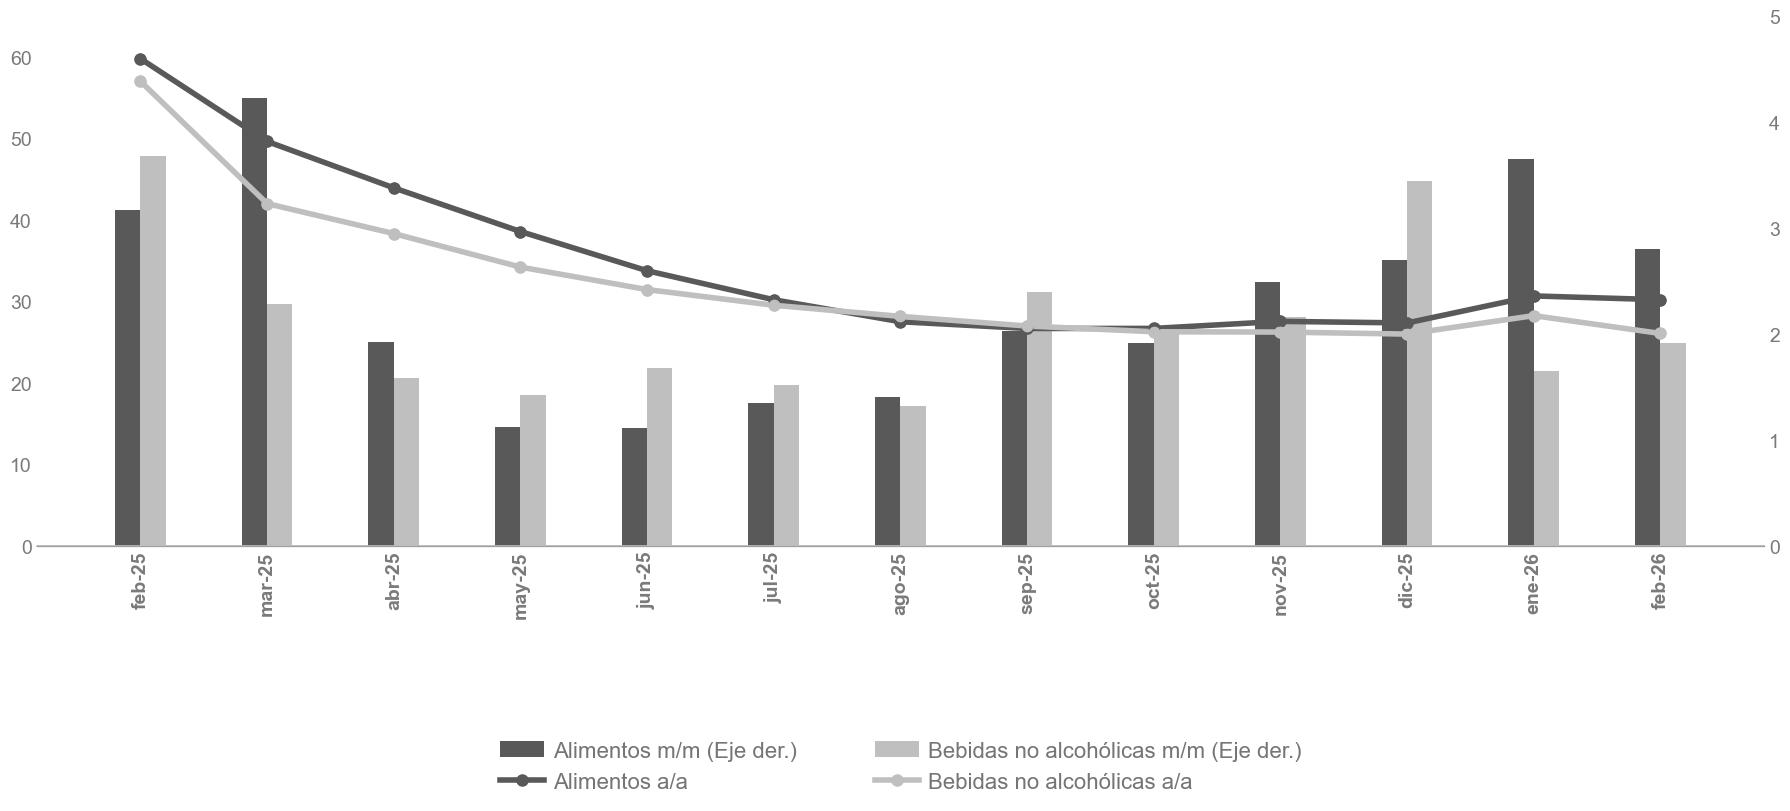

In [20]:
# -----------------------------
# CONFIG EJES
# -----------------------------
y_left_min, y_left_max = 0, 65      # Interanual
y_right_min, y_right_max = 0, 5     # Mensual

# -----------------------------
# DATA PREP
# -----------------------------
alimentos_mm = (
    db_filtrado["alimentos_no_alc_pba"]
    .pct_change(1)
    .mul(100)
    .tail(13)
)

bebidas_mm = (
    db_filtrado["bebidas_no_alc_pba"]
    .pct_change(1)
    .mul(100)
    .tail(13)
)

alimentos_yy = (
    db_filtrado["alimentos_no_alc_pba"]
    .pct_change(12)
    .mul(100)
    .tail(13)
)

bebidas_yy = (
    db_filtrado["bebidas_no_alc_pba"]
    .pct_change(12)
    .mul(100)
    .tail(13)
)

idx = alimentos_yy.index

alimentos_mm = alimentos_mm.reindex(idx)
bebidas_mm = bebidas_mm.reindex(idx)

x = np.arange(len(idx))
ancho = 0.2

# -----------------------------
# FIGURA
# -----------------------------
plt.rcParams["font.family"] = "Arial"

fig, ax_left = plt.subplots(figsize=(18,8))
ax_right = ax_left.twinx()

# ===================================================
# IMPORTANTE
# Las líneas quedan por delante de las barras
# ===================================================

ax_left.set_zorder(2)
ax_right.set_zorder(1)

ax_left.patch.set_alpha(0)

# ===================================================
# BARRAS (Mensual)
# ===================================================

ax_right.bar(
    x-ancho/2,
    alimentos_mm.values,
    width=ancho,
    color="#595959",
    edgecolor="none",
    label="Alimentos m/m (Eje der.)",
    zorder=1
)

ax_right.bar(
    x+ancho/2,
    bebidas_mm.values,
    width=ancho,
    color="#BFBFBF",
    edgecolor="none",
    label="Bebidas no alcohólicas m/m (Eje der.)",
    zorder=1
)

# Labels barras
"""
for i,v in enumerate(alimentos_mm):

    ax_right.text(
        x[i]-ancho/2,
        v+0.06,
        f"{v:.1f}".replace(".",","),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#595959"
    )

for i,v in enumerate(bebidas_mm):

    ax_right.text(
        x[i]+ancho/2,
        v+0.06,
        f"{v:.1f}".replace(".",","),
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#BFBFBF"
    )
"""
# ===================================================
# CURVA ALIMENTOS
# ===================================================

x_smooth = np.linspace(
    x.min(),
    x.max(),
    400
)

ax_left.plot(
    x,
    alimentos_yy,
    color="#595959",
    linewidth=4,
    marker="o",
    markersize=8,
    zorder=5
)


"""
y_alim_smooth = spline(x_smooth)

ax_left.plot(
    x_smooth,
    y_alim_smooth,
    color="#595959",
    linewidth=4,
    zorder=5,
    label="Alimentos a/a"
)
"""

# ===================================================
# CURVA BEBIDAS
# ===================================================

ax_left.plot(
    x,
    bebidas_yy,
    color="#BFBFBF",
    linewidth=4,
    marker="o",
    markersize=8,
    zorder=5
)
"""
y_beb_smooth = spline(x_smooth)

ax_left.plot(
    x_smooth,
    y_beb_smooth,
    color="#BFBFBF",
    linewidth=4,
    zorder=5,
    label="Bebidas no alcohólicas a/a"
)
"""

# ===================================================
# PUNTOS
# ===================================================

ax_left.scatter(
    x,
    alimentos_yy.values,
    s=55,
    color="#595959",
    edgecolors="#595959",
    zorder=6
)

ax_left.scatter(
    x,
    bebidas_yy.values,
    s=55,
    color="#BFBFBF",
    edgecolors="#BFBFBF",
    zorder=6
)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --------------------------------------------------
# EJE X
# --------------------------------------------------

meses_esp = [
    "ene","feb","mar","abr","may","jun",
    "jul","ago","sep","oct","nov","dic"
]

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in idx
]

ax_left.set_xticks(x)
ax_left.set_xticklabels(
    fechas_esp,
    rotation=90,
    fontsize=14,
    fontweight="bold",
    color="#7A7A7A"
)

# --------------------------------------------------
# EJES Y
# --------------------------------------------------

ax_left.set_ylim(
    y_left_min,
    y_left_max
)

ax_right.set_ylim(
    y_right_min,
    y_right_max
)

ax_left.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.0f")
)

ax_right.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.0f")
)

ax_left.tick_params(
    axis="y",
    length=0,
    labelsize=14,
    colors="#7A7A7A"
)

ax_right.tick_params(
    axis="y",
    length=0,
    labelsize=14,
    colors="#7A7A7A"
)

ax_left.tick_params(
    axis="x",
    length=0
)

# --------------------------------------------------
# SPINES
# --------------------------------------------------

ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)

ax_left.spines["right"].set_visible(False)
ax_right.spines["left"].set_visible(False)

ax_left.spines["left"].set_visible(False)
ax_right.spines["right"].set_visible(False)

ax_left.spines["bottom"].set_color("#BFBFBF")
ax_left.spines["bottom"].set_linewidth(1.2)

# --------------------------------------------------
# LINEA BASE
# --------------------------------------------------

ax_right.axhline(
    0,
    color="#BFBFBF",
    linewidth=1.2,
    zorder=0
)

# --------------------------------------------------
# LEYENDA
# --------------------------------------------------

legend_elements = [

    Patch(
        facecolor="#595959",
        edgecolor="none",
        label="Alimentos m/m (Eje der.)"   
    ),

   
    Line2D(
        [0],
        [0],
        color="#595959",
        lw=4,
        marker="o",
        markersize=8,
        label="Alimentos a/a"
    ),

     Patch(
        facecolor="#BFBFBF",
        edgecolor="none",
        label="Bebidas no alcohólicas m/m (Eje der.)"
    ),

    Line2D(
        [0],
        [0],
        color="#BFBFBF",
        lw=4,
        marker="o",
        markersize=8,
        label="Bebidas no alcohólicas a/a"
    )

]

ax_left.legend(
    handles=legend_elements,
    ncol=2,
    frameon=False,
    fontsize=16,
    labelcolor =   '#757575',
    loc="upper center",
    bbox_to_anchor=(0.5,-0.33),
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=3.5
)

# --------------------------------------------------
# MÁRGENES
# --------------------------------------------------

plt.subplots_adjust(
    bottom=0.30,
    left=0.07,
    right=0.93
)

plt.tight_layout()

# plt.savefig(
#     os.path.join(ruta_completa, "grafico_alimentos_bebidas.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()